# Problem to demonstrate the utility of nonlinear regression over linear regression

Get the fgl data set from “MASS” library.  
(a) Considering the refractive index (RI) of “Vehicle Window glass” as the variable of interest and assuming linearity of regression, run multiple linear regression of RI on different metallic oxides. From the p value, report which metallic oxide best explains the refractive index.  
(b) Run a simple linear regression of RI on the best predictor chosen in (a).  
(c) Can you further improve the regression of the refractive index of “Vehicle Window glass” on the predictor chosen by you in part (a)? Give the new fitted model and compare its performance with the model in (b).

In [1]:
import pandas as pd
import statsmodels.api as sm

In [2]:
dataset = sm.datasets.get_rdataset('fgl', 'MASS')
fgl = dataset.data
fgl.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,type
0,3.01,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,WinF
1,-0.39,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,WinF
2,-1.82,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,WinF
3,-0.34,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,WinF
4,-0.58,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,WinF


In [3]:
df = fgl[fgl['type'] == 'Veh']
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,type
146,-0.31,13.65,3.66,1.11,72.77,0.11,8.60,0.0,0.00,Veh
147,-1.90,13.33,3.53,1.34,72.67,0.56,8.33,0.0,0.00,Veh
148,-1.30,13.24,3.57,1.38,72.70,0.56,8.44,0.0,0.10,Veh
149,-1.57,12.16,3.52,1.35,72.89,0.57,8.53,0.0,0.00,Veh
150,-1.35,13.14,3.45,1.76,72.48,0.60,8.38,0.0,0.17,Veh


In [8]:
import statsmodels.formula.api as smf
fit1 = smf.ols("RI ~ Na + Mg + Al + Si + K + Ca + Ba + Fe", data=df).fit()
print(fit1.summary())

                            OLS Regression Results                            
Dep. Variable:                     RI   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     105.9
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           2.62e-07
Time:                        17:32:51   Log-Likelihood:                 5.0461
No. Observations:                  17   AIC:                             7.908
Df Residuals:                       8   BIC:                             15.41
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    131.4641     47.267      2.781      0.0

Smaller the p-values, higher the predictive capability of the predictor. Based on that condition, we see that `Fe` is the strongest predictor of `RI` followed by `Si`. `K` and `Ca` are also great predictors but the aforementioned two completely dominate in terms of performance.

In [9]:
best_reg = smf.ols("RI ~ Fe", data = df).fit()
print(best_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                     RI   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     3.981
Date:                Thu, 19 Feb 2026   Prob (F-statistic):             0.0645
Time:                        17:33:12   Log-Likelihood:                -32.663
No. Observations:                  17   AIC:                             69.33
Df Residuals:                      15   BIC:                             70.99
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5007      0.486     -1.030      0.3

If we add another strong predictor `Si`, then the regression model should improve drastically.

In [21]:
model1 = smf.ols('RI ~ Si + Fe', data = df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                     RI   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     16.47
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           0.000210
Time:                        17:56:47   Log-Likelihood:                -24.379
No. Observations:                  17   AIC:                             54.76
Df Residuals:                      14   BIC:                             57.26
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    204.3016     42.612      4.794      0.0

Based on the summary of the model, we do see that its predictive capability has improved drastically. But, the summary mentions something about a strong presence of multicollinearity. Hence, we can confirm that using VIF (Variance Inflation Factor) and drop the redundant predictors.

# Problem to demonstrate multicollinearity

Consider the Credit data in the ISLR library. Choose balance as the response and Age, Limit and Rating as the predictors.  
(a) Make a scatter plot of  
    i. Age versus Limit and  
    ii. Rating Versus Limit.  
Comment on the scatter plot.  
(b) Run three separate regressions:  
    i. Balance on Age and Limit  
    ii. Balance on Age, Rating and Limit  
    iii. Balance on Rating and Limit.  
Present all the regression output in a single table using stargazer.  
What is the marked difference that you can observe from the output?  
(c) Calculate the variance inflation factor (VIF) and comment on multicollinearity.

In [26]:
df2 = sm.datasets.get_rdataset('Credit', 'ISLR')
Credit = df2.data
Credit.head()

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


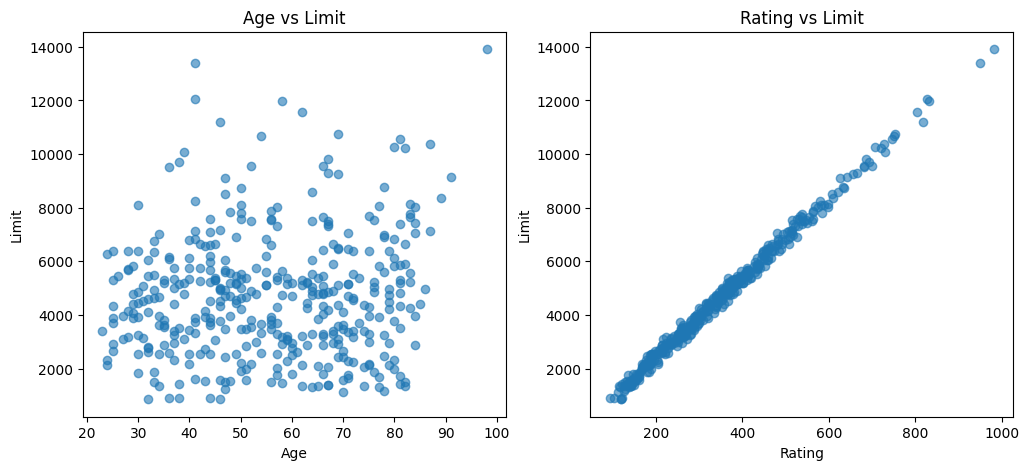

In [42]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(Credit['Age'], Credit['Limit'], alpha = 0.6)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Limit')
axes[0].set_title('Age vs Limit')
axes[1].scatter(Credit['Rating'], Credit['Limit'], alpha = 0.6)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Limit')
axes[1].set_title('Rating vs Limit')
plt.show()


Based on the scatter plots, we can say that there is a moderately strong positive correlation between `Age` and `Limit` whereas there is a very strong positive correlation between `Rating` an `Limit`.

In [49]:
from statsmodels.iolib.summary2 import summary_col
m1 = smf.ols('Balance ~ Age + Limit', data = Credit).fit()
m2 = smf.ols('Balance ~ Age + Rating + Limit', data = Credit).fit()
m3 = smf.ols('Balance ~ Rating + Limit', data = Credit).fit()
print(summary_col([m1, m2, m3],
                  stars = True,
                 model_names = ['Model 1', 'Model 2', 'Model 3'],
                 info_dict = {'F Statistic': lambda x: f"{x.fvalue:.2f}",
                              'No. observations': lambda x: f"{int(x.nobs)}"}))


                   Model 1      Model 2      Model 3   
-------------------------------------------------------
Intercept        -173.4109*** -259.5175*** -377.5368***
                 (43.8284)    (55.8822)    (45.2542)   
Age              -2.2915***   -2.3458***               
                 (0.6725)     (0.6686)                 
Limit            0.1734***    0.0190       0.0245      
                 (0.0050)     (0.0630)     (0.0638)    
Rating                        2.3105**     2.2017**    
                              (0.9395)     (0.9523)    
R-squared        0.7498       0.7536       0.7459      
R-squared Adj.   0.7486       0.7517       0.7447      
F Statistic      594.99       403.72       582.82      
No. observations 400          400          400         
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


Based on the summary table above, we can see that Model 2 has the highest R-squared value followed by Model 1. Further, in Model 2 and 3, we notice that in the specified combinations, `Rating` is always the significant predictor whereas `Limit` is practically insignificant. But in the other model, `Limit` is a very significant predictor. This indicates that there exists multicollinearity between `Rating` and `Limit`.

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 
X = Credit[['Age', 'Rating', 'Limit']]
vif = pd.DataFrame()
X = sm.add_constant(X)
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

  Features         VIF
0    const   23.802955
1      Age    1.011385
2   Rating  160.668301
3    Limit  160.592880


Based on our derivations, we have proved that there exists multicollinearity between `Rating` and `Limit`. So, we can easily drop one of the said predictors and create a non-redundant model.

# Problem to demonstrate the detection of outlier, leverage and influential points

Attach “Boston” data from MASS library in R. Select median value of owner occupied homes, as the response and per capita crime rate, nitrogen oxides concentration, proportion of blacks and percentage of lower status of the population as predictors. The objective is to fit a multiple linear regression model of the response on the predictors. With reference to this problem, detect outliers, leverage points and influential points if any.

In [59]:
df = sm.datasets.get_rdataset('Boston', 'MASS')
boston = df.data
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [62]:
x = boston[['crim', 'nox', 'black', 'lstat']]
y = boston['medv']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     154.1
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           7.32e-86
Time:                        20:40:28   Log-Likelihood:                -1637.3
No. Observations:                 506   AIC:                             3285.
Df Residuals:                     501   BIC:                             3306.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.0536      2.171     13.844      0.0

In [63]:
import numpy as np
influence = model.get_influence()
n = x.shape[0]
p = x.shape[1] - 1
studentized_residuals = influence.resid_studentized_internal
outlier_indices = np.where(np.abs(studentized_residuals) > 3)[0]
print("Outlier indices:", outlier_indices)

Outlier indices: [166 186 195 204 225 257 262 267 283 368 369 371 372 412]
